## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Lani Le

**Date:** 9/30/26

In [5]:
# Your Phase 1 solution to the problem goes here.

1. Regression is used for predicting a numerical target with averages, while classification is used for predicting a categorical target with majority vote.
2. A confusion table is a matrix that displays whether the predictions from a model were actually true or not. It helps us understand the accuracy and precision of a model's performance based on whether and how many were correctly predicted or incorrectly predicted.
3. The SSE quantifies the total error from a model's predictions. The SSE works by squaring each residual, the difference of the actual value and predicted value, and sums them all up, hence why it is called the Sum of Sqaured Errors. Squaring each residual, will remove the sign from the residual since it will make it positive, and it will also make it so that larger residual values will have a greater impact than smaller ones.
4. Overfitting is when the model is too flexible and it memorizes the specific randomness of training data and continues following that specific trend. Underfitting is when the model is too simple that is does not accurately capture the trend of the set of data.
5. By splitting the data into training and testing sets, we can use the training set to create a model and then, we can use the model on the test set to cross check and see how well the model performs with predicting new observations.
6. Reporting a class label is very simple so it would not require a lot of memory space, but it would have a lot less information. Reporting a probability distribution allows us to see the confidence level of the predictions, but it would take a lot more memory space to do all this, especially if the dataset was very large."

In [154]:
print('-------------------- Question 1 --------------------')

#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # importing function to split data
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# loading the file in
df = pd.read_csv('land_mines.csv')


-------------------- Question 1 --------------------


In [155]:
df.describe() # provides info like mean, std, quartiles, min, and max

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [156]:
# checking for missing values
print(df.isnull().sum()) # checking each individual column for missing values
# there are no missing values

voltage      0
height       0
soil         0
mine_type    0
dtype: int64


[Text(0.5, 1.0, 'Mine Type vs. Soil'),
 Text(0.5, 0, 'Mine Type'),
 Text(0, 0.5, 'Soil Value')]

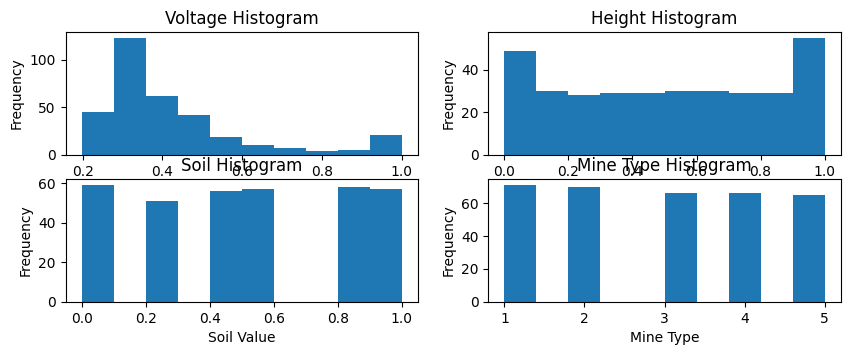

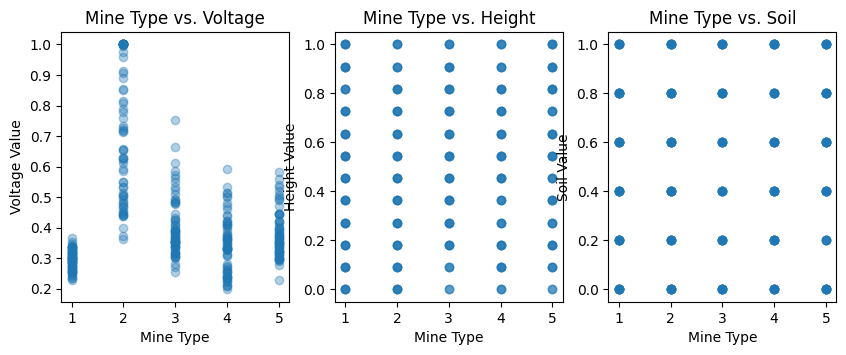

In [157]:
# plotting histograms for each variable
fig, axes = plt.subplots(2, 2, figsize=(10, 3.5))

df['voltage'].plot.hist(ax=axes[0,0])
axes[0,0].set(title='Voltage Histogram', xlabel='Voltage Value')

df['height'].plot.hist(ax=axes[0,1])
axes[0,1].set(title='Height Histogram', xlabel='Height Value')


df['soil'].plot.hist(ax=axes[1,0])
axes[1,0].set(title='Soil Histogram', xlabel='Soil Value')

df['mine_type'].plot.hist(ax=axes[1,1])
axes[1,1].set(title='Mine Type Histogram', xlabel='Mine Type')


# plotting scatterplots
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].scatter(df['mine_type'], df['voltage'], alpha=0.35)
axes[0].set(title='Mine Type vs. Voltage', xlabel = 'Mine Type', ylabel='Voltage Value')

axes[1].scatter(df['mine_type'], df['height'], alpha=0.35)
axes[1].set(title='Mine Type vs. Height', xlabel = 'Mine Type', ylabel='Height Value')

axes[2].scatter(df['mine_type'], df['soil'], alpha=0.35)
axes[2].set(title='Mine Type vs. Soil', xlabel = 'Mine Type', ylabel='Soil Value')


In [158]:
print('Findings: \n - 4 variables: voltage, height, soil, and mine type \n - target label is mine type \n - 0 missing values \n - information on mean, std, quartiles, min, and max can be found from the .describe() function \n - volage histogram was right skewed \n - not much skew in soil and height histograms \n - on the scatterplots for Mine Type vs. Height and Mine Type vs. Soil, the datapoints look evenly spread \n - scatterplot for Mine Type vs. Voltage has clusters')

Findings: 
 - 4 variables: voltage, height, soil, and mine type 
 - target label is mine type 
 - 0 missing values 
 - information on mean, std, quartiles, min, and max can be found from the .describe() function 
 - volage histogram was right skewed 
 - not much skew in soil and height histograms 
 - on the scatterplots for Mine Type vs. Height and Mine Type vs. Soil, the datapoints look evenly spread 
 - scatterplot for Mine Type vs. Voltage has clusters


In [159]:
print('-------------------- Question 2 --------------------')
eval_X_raw = df[['voltage', 'height', 'soil']]
eval_y = df['mine_type']

# splitting the sample 50/50 into training and test/validation sets
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65, stratify=eval_y
)

# fitting the scalar
eval_scaler = MinMaxScaler()
eval_X_train_scaled = pd.DataFrame(eval_scaler.fit_transform(eval_X_train_raw))
eval_X_valid_scaled = pd.DataFrame(eval_scaler.transform(eval_X_valid_raw))

# viewing split samples
eval_X_train_scaled.head()

-------------------- Question 2 --------------------


,0,1,2
0,0.408781,0.272727,0.2
1,0.053400,0.636364,0.0
2,0.385895,0.090909,0.2
3,0.032879,0.727273,0.4
4,0.088378,0.272727,0.0


In [109]:
eval_X_valid_scaled.head()

,0,1,2
0,1.000000,0.181818,0.6
1,0.343937,0.454545,0.2
2,0.141778,0.090909,0.0
3,0.084564,0.454545,0.2
4,0.412595,0.000000,0.2


In [160]:
print('-------------------- Question 3 --------------------')

eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print('Validation SSE is lowest at k =', eval_k_star)
print('I selected k by looping through all the values of k from 1 to 50 and then generating predictions and calculating the SSE. I chose the k value that has the lowest SSE.')

-------------------- Question 3 --------------------
Validation SSE is lowest at k = 2
I selected k by looping through all the values of k from 1 to 50 and then generating predictions and calculating the SSE. I chose the k value that has the lowest SSE.


In [161]:
print('-------------------- Question 4 --------------------')
best_knn = KNeighborsClassifier(n_neighbors=eval_k_star)
best_knn.fit(eval_X_train_scaled, eval_y_train)

eval_valid_preds = np.clip(np.round(best_knn.predict(eval_X_valid_scaled)), 1, 5)
print('Confusion Matrix:')
print(confusion_matrix(eval_y_valid, eval_valid_preds))

correct_predictions = np.sum(eval_y_valid.to_numpy() == eval_valid_preds)
total_samples = len(eval_y_valid)
eval_test_acc = correct_predictions / total_samples

print('\n Validation Accuracy: ', eval_test_acc)
print("From the Confusion Matrix, we can see that the model's performance is most accurate for Mine Type 2, as it had 31 correct predictions, which was the highest amount.")
print("Performance was less accurate for Type 3, 4, and 5, but specifically Type 5, where  it only predicted 2 correctly.")

-------------------- Question 4 --------------------
Confusion Matrix:
[[27  0  5  2  2]
 [ 0 31  2  1  1]
 [10  2 10 10  1]
 [15  6  3  9  0]
 [15  0 10  5  2]]

 Validation Accuracy:  0.46745562130177515
From the Confusion Matrix, we can see that the model's performance is most accurate for Mine Type 2, as it had 31 correct predictions, which was the highest amount.
Performance was less accurate for Type 3, 4, and 5, but specifically Type 5, where  it only predicted 2 correctly.


In [162]:
print('-------------------- Question 5 --------------------')
print('Because there is still chance for a lot of mistakes using a model to make predictions, people should use these predictive models with caution, making sure to consider how accurate it was from the confusion matrix. For example, because Type 2 was pretty accurate that can likely be used to predict values, but the other Types, not so much There should also probably be a confidence interval that go with these predictions.')

-------------------- Question 5 --------------------
Because there is still chance for a lot of mistakes using a model to make predictions, people should use these predictive models with caution, making sure to consider how accurate it was from the confusion matrix. For example, because Type 2 was pretty accurate that can likely be used to predict values, but the other Types, not so much There should also probably be a confidence interval that go with these predictions.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
print("")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]